In [34]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import joblib
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv('HC_application_train.csv')
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#check imbalanced
print(df['TARGET'].value_counts(normalize=True))
print(df.shape)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
(307511, 122)


In [4]:
df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [10]:
df['DAYS_EMPLOYED'].value_counts().head()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

In [9]:
#check missing value
df.isnull().mean().sort_values(ascending=False).head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64

In [3]:
df_bureau = pd.read_csv('HC_bureau.csv')
df_bureau.head(5)

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [12]:
df_bureau['SK_ID_CURR'].value_counts().describe()

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: count, dtype: float64

In [14]:
df_bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [13]:
df_bureau.columns.tolist()

['SK_ID_CURR',
 'SK_ID_BUREAU',
 'CREDIT_ACTIVE',
 'CREDIT_CURRENCY',
 'DAYS_CREDIT',
 'CREDIT_DAY_OVERDUE',
 'DAYS_CREDIT_ENDDATE',
 'DAYS_ENDDATE_FACT',
 'AMT_CREDIT_MAX_OVERDUE',
 'CNT_CREDIT_PROLONG',
 'AMT_CREDIT_SUM',
 'AMT_CREDIT_SUM_DEBT',
 'AMT_CREDIT_SUM_LIMIT',
 'AMT_CREDIT_SUM_OVERDUE',
 'CREDIT_TYPE',
 'DAYS_CREDIT_UPDATE',
 'AMT_ANNUITY']

In [4]:
agg_col_bureau = df_bureau.groupby('SK_ID_CURR').agg({'AMT_CREDIT_SUM_DEBT' : 'sum',
                                                      'AMT_CREDIT_SUM_OVERDUE' : 'sum',
                                                      'DAYS_CREDIT' : ['min', 'max', 'mean'],
                                                      'CREDIT_DAY_OVERDUE' : ['sum', 'max']
                                                      })
print(agg_col_bureau.columns)
agg_col_bureau

MultiIndex([(   'AMT_CREDIT_SUM_DEBT',  'sum'),
            ('AMT_CREDIT_SUM_OVERDUE',  'sum'),
            (           'DAYS_CREDIT',  'min'),
            (           'DAYS_CREDIT',  'max'),
            (           'DAYS_CREDIT', 'mean'),
            (    'CREDIT_DAY_OVERDUE',  'sum'),
            (    'CREDIT_DAY_OVERDUE',  'max')],
           )


AMT_CREDIT_SUM_DEBT AMT_CREDIT_SUM_OVERDUE DAYS_CREDIT        \
                           sum                    sum         min   max   
SK_ID_CURR                                                                
100001              596686.500                    0.0       -1572   -49   
100002              245781.000                    0.0       -1437  -103   
100003                   0.000                    0.0       -2586  -606   
100004                   0.000                    0.0       -1326  -408   
100005              568408.500                    0.0        -373   -62   
...                        ...                    ...         ...   ...   
456249              163071.000                    0.0       -2713  -483   
456250             2232040.095                    0.0       -1002  -760   
456253             1795833.000                    0.0        -919  -713   
456254                   0.000                    0.0       -1104 -1104   
456255             1534913.010                    0.0       -2337  -363   

                        CREDIT_DAY_OVERDUE      
                   mean                sum max  
SK_ID_CURR                                      
100001      -735.000000                  0   0  
100002      -874.000000                  0   0  
100003     -1400.750000                  0   0  
100004      -867.000000                  0   0  
100005      -190.666667                  0   0  
...                 ...                ...  ..  
456249     -1667.076923                  0   0  
456250      -862.000000                  0   0  
456253      -867.500000                  0   0  
456254     -1104.000000                  0   0  
456255     -1089.454545                  0   0  

[305811 rows x 7 columns]

In [5]:
agg_col_bureau.columns = ['_'.join(col) for col in agg_col_bureau.columns]
agg_col_bureau.columns


Index(['AMT_CREDIT_SUM_DEBT_sum', 'AMT_CREDIT_SUM_OVERDUE_sum',
       'DAYS_CREDIT_min', 'DAYS_CREDIT_max', 'DAYS_CREDIT_mean',
       'CREDIT_DAY_OVERDUE_sum', 'CREDIT_DAY_OVERDUE_max'],
      dtype='str')

In [6]:
agg_col_bureau = agg_col_bureau.reset_index()

In [ ]:
merge_data = df.merge(agg_col_bureau, on='SK_ID_CURR', how='left')



NameError: name 'df' is not defined

In [25]:
merge_data.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_sum,DAYS_CREDIT_min,DAYS_CREDIT_max,DAYS_CREDIT_mean,CREDIT_DAY_OVERDUE_sum,CREDIT_DAY_OVERDUE_max
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,1.0,245781.0,0.0,-1437.0,-103.0,-874.00,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,-2586.0,-606.0,-1400.75,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,-1326.0,-408.0,-867.00,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,-1149.0,-1149.0,-1149.00,0.0,0.0


In [27]:
print(merge_data.shape)
print(merge_data[['DAYS_CREDIT_min', 'AMT_CREDIT_SUM_DEBT_sum']].isnull().sum())

(307511, 129)
DAYS_CREDIT_min            44020
AMT_CREDIT_SUM_DEBT_sum    44020
dtype: int64


In [8]:
train_ids = set(df['SK_ID_CURR'])
bureau_ids = set(df_bureau['SK_ID_CURR'])

overlap = train_ids & bureau_ids        # irisan: klien train yang ADA di bureau
missing = train_ids - bureau_ids        # klien train yang TIDAK ADA di bureau

print(len(overlap))
print(len(missing))

263491
44020


In [9]:
merge_data['HAS_BUREAU_HISTORY'] = merge_data['DAYS_CREDIT_min'].notnull().astype(int)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17044\277749066.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merge_data['HAS_BUREAU_HISTORY'] = merge_data['DAYS_CREDIT_min'].notnull().astype(int)


In [10]:
merge_data['HAS_BUREAU_HISTORY'] = merge_data['DAYS_CREDIT_min'].notnull().astype(int)

cols_fill_zero = ['AMT_CREDIT_SUM_DEBT_sum', 'AMT_CREDIT_SUM_OVERDUE_sum', 'CREDIT_DAY_OVERDUE_max', 'CREDIT_DAY_OVERDUE_sum']
merge_data[cols_fill_zero] = merge_data[cols_fill_zero].fillna(0)
merge_data[cols_fill_zero + ['DAYS_CREDIT_min']].isnull().sum()

AMT_CREDIT_SUM_DEBT_sum           0
AMT_CREDIT_SUM_OVERDUE_sum        0
CREDIT_DAY_OVERDUE_max            0
CREDIT_DAY_OVERDUE_sum            0
DAYS_CREDIT_min               44020
dtype: int64

In [11]:
merge_data['DAYS_EMPLOYED_ANOM'] = (merge_data['DAYS_EMPLOYED'] == 365243).astype(int)
merge_data['DAYS_EMPLOYED'] = merge_data['DAYS_EMPLOYED'].replace(365243, np.nan)

print(merge_data['DAYS_EMPLOYED_ANOM'].sum())
print(merge_data['DAYS_EMPLOYED'].max())

55374
0.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17044\2162658278.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merge_data['DAYS_EMPLOYED_ANOM'] = (merge_data['DAYS_EMPLOYED'] == 365243).astype(int)


In [12]:
missing_pct = merge_data.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
print(len(cols_to_drop))
print(cols_to_drop)

49
['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_M

In [13]:
keep_cols = ['EXT_SOURCE_1', 'OWN_CAR_AGE']
cols_to_drop = [col for col in cols_to_drop if col not in keep_cols]
print(len(cols_to_drop))  # harusnya sekarang 47

47


In [14]:
merge_data = merge_data.drop(columns=cols_to_drop)
print(merge_data.shape)

(307511, 84)


In [15]:
print('EXT_SOURCE_1' in merge_data.columns)
print('OWN_CAR_AGE' in merge_data.columns)

True
True


In [17]:
#cek kolom kategorical
cat_cols = merge_data.select_dtypes(include='object').columns.tolist()
print(len(cat_cols))
print(cat_cols)

12
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17044\2846832295.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = merge_data.select_dtypes(include='object').columns.tolist()


In [36]:
print(merge_data['CODE_GENDER'].value_counts())
print(merge_data['ORGANIZATION_TYPE'].value_counts())

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Servic

In [18]:
print((merge_data['ORGANIZATION_TYPE'] == 'XNA').sum())
print(merge_data['DAYS_EMPLOYED_ANOM'].sum())

# cek overlap-nya
overlap_check = merge_data[merge_data['ORGANIZATION_TYPE'] == 'XNA']['DAYS_EMPLOYED_ANOM'].value_counts()
print(overlap_check)

55374
55374
DAYS_EMPLOYED_ANOM
1    55374
Name: count, dtype: int64


In [19]:
#convert kolom kategorikal ke dtype category
for col in cat_cols:
    merge_data[col]=merge_data[col].astype('category')

In [20]:
merge_data[cat_cols].dtypes

NAME_CONTRACT_TYPE            category
CODE_GENDER                   category
FLAG_OWN_CAR                  category
FLAG_OWN_REALTY               category
NAME_TYPE_SUITE               category
NAME_INCOME_TYPE              category
NAME_EDUCATION_TYPE           category
NAME_FAMILY_STATUS            category
NAME_HOUSING_TYPE             category
OCCUPATION_TYPE               category
WEEKDAY_APPR_PROCESS_START    category
ORGANIZATION_TYPE             category
dtype: object

In [21]:
X = merge_data.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = merge_data['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
print('SK_ID_CURR' in X.columns)  # harus False

False


In [23]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [46]:
model = xgb.XGBClassifier(
    enable_categorical=True, #supaya bida memproses kolom bertipe kategorical
    eval_metric ='aucpr', #nama metric di XGBoost
    random_state = 42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('PR-AUC', average_precision_score(y_test, y_pred_proba))


              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.46      0.04      0.08      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503

PR-AUC 0.23338831738021446


In [ ]:
xgb.XGBClassifier

Init signature:
xgb.XGBClassifier(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with highest loss change.

    learning_rate : typing.Optional[f

In [24]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

11.38710976837865


In [25]:
model_weighted = xgb.XGBClassifier(
    enable_categorical=True,
    eval_metric='aucpr',
    scale_pos_weight=11.4,
    random_state=42
)

model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
y_pred_proba_weighted = model_weighted.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_weighted))
print('PR-AUC', average_precision_score(y_test, y_pred_proba_weighted))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.18      0.60      0.28      4965

    accuracy                           0.75     61503
   macro avg       0.57      0.68      0.56     61503
weighted avg       0.89      0.75      0.80     61503

PR-AUC 0.23201648943169575


In [26]:
precisions, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_weighted)

pr_table= pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall' : recall[:-1]}   
)
print(pr_table[pr_table['recall'] >= 0.5].head(10))

   threshold  precision  recall
0   0.000168   0.080728     1.0
1   0.000266   0.080729     1.0
2   0.000398   0.080730     1.0
3   0.000465   0.080732     1.0
4   0.000543   0.080733     1.0
5   0.000563   0.080734     1.0
6   0.000662   0.080736     1.0
7   0.000690   0.080737     1.0
8   0.000695   0.080738     1.0
9   0.000798   0.080740     1.0


In [27]:
pr_table_filtered = pr_table[(pr_table['recall'] >= 0.5) & (pr_table['recall'] <= 0.7)]
print(pr_table_filtered.iloc[::200])  # ambil sampel tiap 200 baris biar nggak kepanjangan

       threshold  precision    recall
38909   0.412746   0.154061  0.699899
39109   0.415565   0.154789  0.696878
39309   0.418298   0.155690  0.694663
39509   0.420762   0.156471  0.691843
39709   0.423141   0.157312  0.689225
39909   0.425972   0.158215  0.686808
40109   0.428964   0.159181  0.684592
40309   0.431288   0.159788  0.680765
40509   0.433693   0.160407  0.676939
40709   0.435817   0.161037  0.673112
40909   0.438529   0.161874  0.670091
41109   0.441437   0.162482  0.666062
41309   0.444651   0.163118  0.662034
41509   0.447386   0.163851  0.658409
41709   0.450517   0.164861  0.655791
41909   0.453221   0.165524  0.651762
42109   0.456314   0.165788  0.646123
42309   0.459346   0.166432  0.641893
42509   0.462233   0.167458  0.639074
42709   0.464916   0.168658  0.636858
42909   0.467858   0.169614  0.633635
43109   0.471031   0.170055  0.628399
43309   0.473835   0.170662  0.623766
43509   0.476781   0.172006  0.621752
43709   0.479955   0.173166  0.618933
43909   0.48

In [28]:
threshold = 0.43
y_pred_custom = (y_pred_proba_weighted >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.68      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.68      0.76     61503



In [29]:
pr_table_80 = pr_table[(pr_table['recall'] >= 0.75) & (pr_table['recall'] <= 0.85)]
print(pr_table_80.iloc[::100])

       threshold  precision    recall
26213   0.264508   0.119642  0.849950
26313   0.265684   0.119953  0.849748
26413   0.266578   0.120156  0.848741
26513   0.267635   0.120242  0.846928
26613   0.268640   0.120473  0.846123
...          ...        ...       ...
35013   0.363536   0.141616  0.754884
35113   0.364708   0.141963  0.753877
35213   0.365773   0.142275  0.752669
35313   0.366983   0.142590  0.751460
35413   0.368163   0.142989  0.750655

[93 rows x 3 columns]


In [30]:
explainer = shap.TreeExplainer(model_weighted)
shap_values = explainer.shap_values(X_test)

In [32]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(61503, 82)


In [33]:
print(X_test.shape)

(61503, 82)


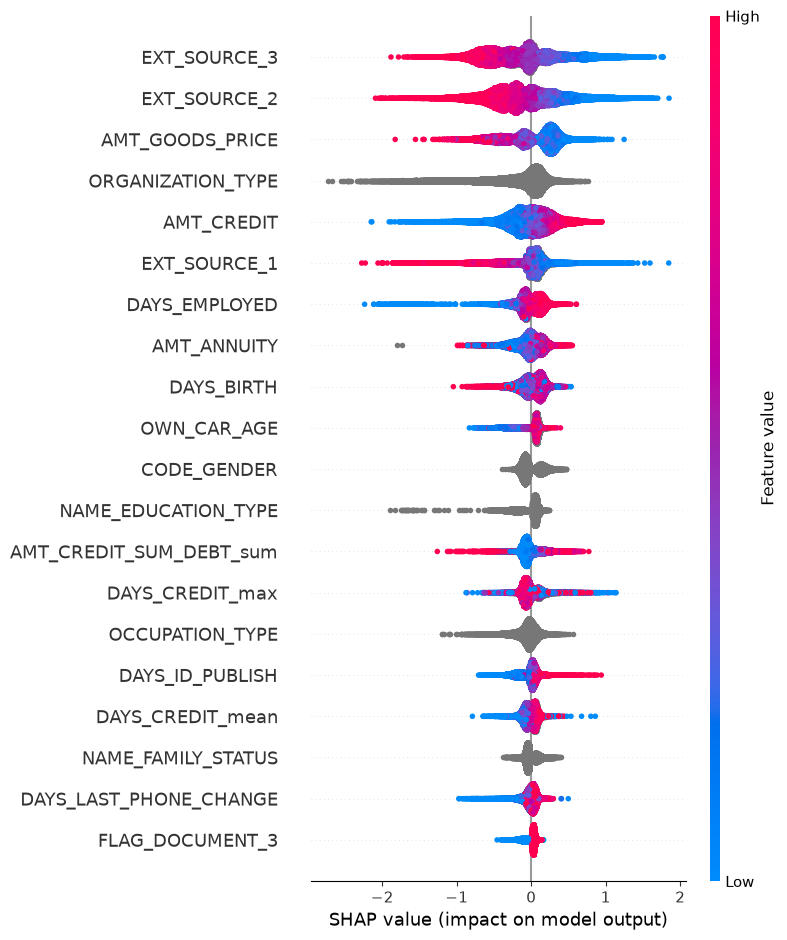

In [35]:
shap.summary_plot(shap_values, X_test)

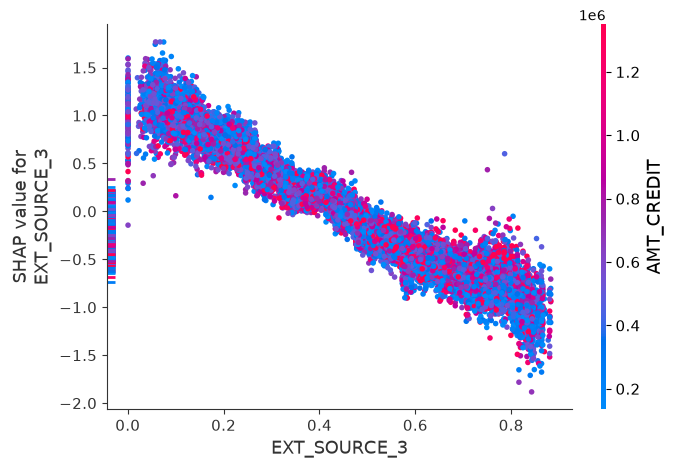

In [37]:
shap.dependence_plot('EXT_SOURCE_3', shap_values, X_test, interaction_index='AMT_CREDIT')

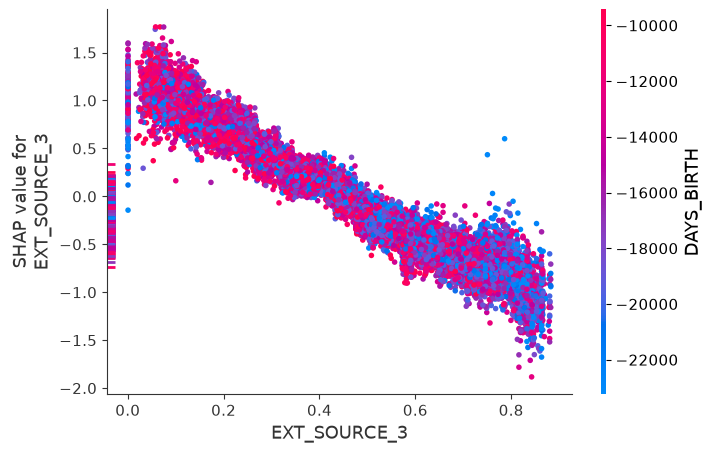

In [38]:
shap.dependence_plot('EXT_SOURCE_3', shap_values, X_test, interaction_index='DAYS_BIRTH')

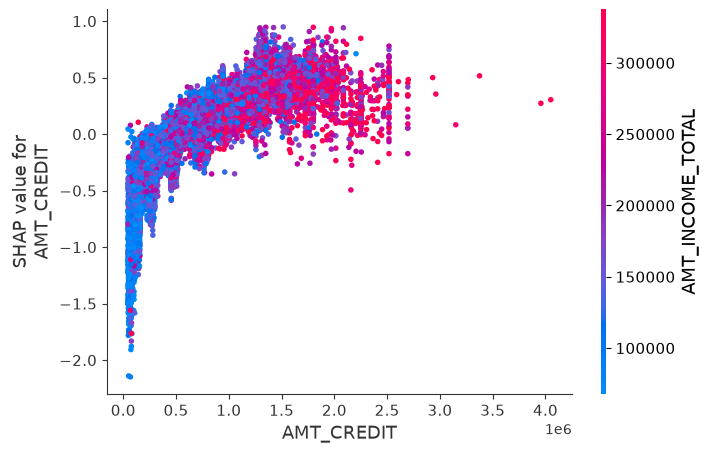

In [39]:
shap.dependence_plot('AMT_CREDIT', shap_values, X_test, interaction_index='AMT_INCOME_TOTAL')

In [40]:
joblib.dump(model_weighted, 'home_credit_xgb_model.joblib')

['home_credit_xgb_model.joblib']